# Лабораторная работа 4. Введение в машинное обучение: knn, деревянные алгоритмы и ансамблирование. Анализ и сравнение.

![](https://newapplift-production.s3.amazonaws.com/comfy/cms/files/files/000/001/201/original/machine-learning-robots-dilbert.gif)

Результат лабораторной работы − отчет. Мы предпочитаем принимать отчеты в формате ноутбуков Jupyter (ipynb-файл). Постарайтесь сделать ваш отчет интересным рассказом, последовательно отвечающим на вопросы из заданий. Помимо ответов на вопросы, в отчете так же должен быть код, однако чем меньше кода, тем лучше всем: нам − меньше проверять, вам —  проще найти ошибку или дополнить эксперимент. При проверке оценивается четкость ответов на вопросы, аккуратность отчета и кода.


### Оценивание и штрафы
* Не копируйте классы между заданиями, объявите решающие модели один раз, а затем их инстанциируйте в каждой из ячеек
* Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи).
* Максимально допустимая оценка за работу — 22 балла. При выставлении оценки будут учитываться только 14 балла за эту лабораторную, 8 баллов считаются дополнительными.
* Сдавать задание после указанного срока сдачи нельзя.
* Не оцениваются задания с удалёнными формулировками.
* Не оценивается лабораторная работа целиком, если она была выложена в открытый источник.


## Метрика качества

Обучение и оценка качества модели производятся на независимых множествах примеров. Как правило, имеющующиеся примеры разбивают на два подмножества: обучающее (train) и тестовое (test). Выбор пропорции разбиения — компромисс. Действительно, большой размер обучения ведет к более качественным алгоритмам, но бОльшему шуму при оценке модели на тесте. И наоборот, большой размер тестовой выборки ведет к менее шумной оценке качества, однако обученные модели получаются менее точными.

Многие модели классификации предсказывают оценку принадлежности положительному классу $\tilde{y}(x) \in R$ (например, вероятность принадлежности классу 1). После этого принимают решение о классе объекта путем сравнения оценки с некоторым порогом $\theta$:

$$y(x) = 
\begin{cases}
+1, &\text{если} \; \tilde{y}(x) \geq \theta \\
-1, &\text{если} \; \tilde{y}(x) < \theta
\end{cases}
$$

В этом случае можно рассматривать метрики, которые умеют работать с исходным ответом классификатора. В задании мы будем работать с метрикой AUC-ROC, которую в данном случае можно считать как долю неправильно упорядоченных пар объектов, отсортированных по возрастанию предсказанной оценки принадлежности классу 1 (более подробно можно узнать на следующих лекциях или, например, [здесь](https://github.com/esokolov/ml-course-msu/blob/master/ML15/lecture-notes/Sem05_metrics.pdf)). Детального понимания принципов работы метрики AUC-ROC для выполнения этой лабораторной не требуется. В sklearn данная метрика реализуется [следующей функцией](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html).

# Подбор гиперпараметров и сравнение моделей (14-22 баллов)

В этом задании также можно получить дополнительные баллы за использование ваших реализаций алгоритмов при сравнении: knn, decision tree, random forest, mlp.

Баллы будут засчитываться, только если вы при решении заданий будете использовать только вашу реализацию алгоритма или алгоритмов и решите как минимум 4 задания.

Дополнительные баллы следующие:
1. knn (с предыдущей лабы):
   1. plain knn - 1 балл
   2. ann - 2 балла
2. decision tree - 2 балла
3. random forest:
   1. random forest на деревьях из sklearn - 1 балл
   2. random forest на собственной реализации деревьев - 2 балла
4. MLP (с предыдущей лабы):
   1. Своя реализация MLP - 2 балла

Перед решением данного задания, опишите в окошке снизу, какие ваши реализации вы будете использовать, чтобы я их не пропустил случайно:

In [410]:
import pandas as pd
import numpy as np

In [ ]:
# Я буду использовать свою реализацию DecisionTreeClassifier -> MyCoolDecisionTreeClassifierOptimized


"""
My decision Trees
"""
from sklearn.base import BaseEstimator, ClassifierMixin
from typing import Literal


class TreeNode:
    def __init__(self, depth: int | None = None) -> None:
        self.depth = depth or 0
        self._answer = None
        self.feature_idx = None
        self.value = None
        self.left = None
        self.right = None

    @property
    def answer(self):
        assert self._answer is not None, "answer should be specified"
        return self._answer

    @answer.setter
    def answer(self, v: float):
        self._answer = v

    @property
    def is_leaf(self):
        assert (
            self.left is not None or self.right is None
        ), "all child should or shouldn't be"
        assert (
            self.left is None or self.right is not None
        ), "all child should or shouldn't be"
        return self.left is None and self.right is None

    def predict(self, x):
        if self.is_leaf:
            return self.answer
        
        assert (
            self.feature_idx is not None and self.value is not None
        ), "at prediction split values should be specified"

        if x[self.feature_idx] < self.value:
            return self.left.predict(x)
        else:
            return self.right.predict(x)


class MyCoolDecisionTree(ClassifierMixin, BaseEstimator):
    def __init__(
        self,
        max_depth: int | None = None,
        min_samples_leaf: int | None = None,
        min_samples_split: int | None = None,
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = TreeNode(depth=1)
        self.classes_ = None

    def _build_tree(self, node: TreeNode, X, y) -> TreeNode:
        
        if self._stop_criterion(node, X):
            node.answer = self._get_answer(X, y)
            return node

        _, optimal_border = self._get_split(X, y)
        if optimal_border is None:
            node.answer = self._get_answer(X, y)
            return node

        feature_idx, t = optimal_border 
        mask = (X[:, feature_idx] < t)
        node.feature_idx = feature_idx
        node.value = t

        X_l, y_l = X[mask], y[mask]
        X_r, y_r = X[~mask], y[~mask]

        left = TreeNode(node.depth + 1)
        right = TreeNode(node.depth + 1)
        node.left = self._build_tree(left, X_l, y_l)
        node.right = self._build_tree(right, X_r, y_r)

        return node


    def _stop_criterion(self, node: TreeNode, X) -> bool:
        if (
            node.depth >= self.max_depth
            or X.shape[0] < 2 * self.min_samples_leaf
            or X.shape[0] < self.min_samples_split
        ):
            return True
        else:
            return False
    

    def _get_split(self, X, y):
        min_loss = float("+inf")
        optimal_border = None

        for j in range(X.shape[1]):
            values = X[:, j]
           
            thresholds = (values[:-1] + values[1:]) / 2.0 # Используем значения порогов между значений фичей
            thresholds = thresholds[thresholds > 1e-12]
            for t in thresholds:
                loss = self._get_criterion(X, y, j, t)
                if loss < min_loss:
                    min_loss, optimal_border = loss, (j, t)

        return min_loss, optimal_border


    def _get_criterion(self, X, y, feature_idx, value):
        mask = (X[:, feature_idx] < value)
        X_l, y_l = X[mask], y[mask]
        X_r, y_r = X[~mask], y[~mask]

        return ((X_l.shape[0] / X.shape[0]) * self._H(X_l, y_l) + 
                (X_r.shape[0] / X.shape[0]) * self._H(X_r, y_r))


    def _H(self, X, y):
        if y.shape[0] == 0:
            return np.float32("+inf")
        cnts = np.unique_counts(y)
        k_count = cnts.counts.max()

        return 1. - k_count / X.shape[0]


    def _get_answer(self, X, y):
        if X.shape[0] == 0:
            return np.ones(len(self.classes_)) / len(self.classes_)
        result = []
        for k in self.classes_:
            p_k = np.sum(y == k) / X.shape[0]
            result.append(p_k)
        return np.array(result)

    def _mse_loss(self, y):
        return np.var(y)

    def _mae_loss(self, y):
        return np.abs(y - np.median(y)).mean()

    def fit(self, X, y):
        self.min_samples_split = self.min_samples_split or 2
        self.min_samples_leaf = self.min_samples_leaf or 1
        self.classes_ = np.unique(y)
        self._build_tree(self.root, X, y)
        return self

    def predict_proba(self, X):
        scores = []
        for x in X:
            scores.append(self.root.predict(x))
        return np.array(scores)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)



class MyCoolDecisionTreeClassifier(MyCoolDecisionTree):
    def __init__(self, 
                 max_depth: int | None = None, 
                 min_samples_leaf: int | None = None, 
                 min_samples_split: int | None = None,
                 criterion: Literal["gini", "misclserr"] = "gini"):
        super().__init__(
            max_depth, 
            min_samples_leaf, 
            min_samples_split)
        
        self.criterion = criterion
    
    def _H(self, X, y):
        if y.shape[0] == 0:
            return np.float32("+inf")
        
        cnts = np.unique_counts(y)
        if self.criterion == "misclserr":
            k_count = cnts.counts.max()
            return 1. - k_count / X.shape[0]
        
        elif self.criterion == "gini":
            p_ks = cnts.counts / y.shape[0]
            return 1 - np.sum(p_ks ** 2)
        
        else:
            raise ValueError(f"criterion: {self.criterion} is invalid!")

    

class MyCoolDecisionTreeClassifierOptimized(MyCoolDecisionTreeClassifier):
    def __init__(self, 
                 max_depth = None, 
                 min_samples_leaf = None, 
                 min_samples_split = None, 
                 criterion = "gini"):
        super().__init__(
            max_depth, 
            min_samples_leaf, 
            min_samples_split, 
            criterion)
        
        self._precount = None
    


    def _get_split(self, X, y):
        min_loss = float("+inf")
        optimal_border = None

        for j in range(X.shape[1]):
            sorted_idx = np.argsort(X[:, j])
            sorted_x = X[sorted_idx, j]
            self._precount = None

            for i in range(X.shape[0] - 1):
                loss = self._get_criterion(y, sorted_idx, i)

                if np.abs(sorted_x[i] - sorted_x[i + 1]) < 1e-12:
                    continue
                if loss < min_loss:
                    min_loss = loss
                    threshold = (sorted_x[i] + sorted_x[i + 1]) / 2.0
                    optimal_border = (j, threshold)

        return min_loss, optimal_border
    


    def _get_criterion(self, y, sorted_idx, index):
        if index == y.shape[0] - 1:
            return np.float32("+inf")

        if self._precount is None:
            class_to_index = {c: i for i, c in enumerate(self.classes_)}
            vals, counts = np.unique(y, return_counts=True)

            right_counts = np.zeros(len(self.classes_), dtype=int)
            for v, c in zip(vals, counts):
                right_counts[class_to_index[v]] = c

            self._precount = {
                "left_counts": np.zeros(len(self.classes_), dtype=int),
                "right_counts": right_counts,
                "left_max_count": 0,
                "right_maxes": self._get_right_maxes(y, sorted_idx),
                "class_to_index": class_to_index,
            }

        cls = y[sorted_idx[index]]
        cls_idx = self._precount["class_to_index"][cls]

        self._precount["left_counts"][cls_idx] += 1
        self._precount["right_counts"][cls_idx] -= 1

        self._precount["left_max_count"] = max(
            self._precount["left_max_count"],
            self._precount["left_counts"][cls_idx],
        )

        right_max_count = int(self._precount["right_maxes"][index + 1])

        return self._H(index, y.shape[0], right_max_count)


    def _H(self, index, n_samples, right_max_count):
        left_n = index + 1
        right_n = n_samples - left_n

        if left_n == 0 or right_n == 0:
            return np.float32("+inf")
        
        
        if self.criterion == "misclserr":
            left_err = 1.0 - self._precount["left_max_count"] / left_n
            right_err = 1.0 - right_max_count / right_n
            return ((left_n / n_samples) * left_err + 
                    (right_n / n_samples) * right_err)

        elif self.criterion == "gini":
            left_p = self._precount["left_counts"] / left_n
            right_p = self._precount["right_counts"] / right_n
            return ((left_n / n_samples) * (1.0 - np.sum(left_p ** 2)) + 
                    (right_n / n_samples) * (1.0 - np.sum(right_p ** 2)))

        else:
            raise ValueError(f"criterion {self.criterion} is invalid")

    
    def _get_right_maxes(self, y, sorted_idx):
        result = np.zeros_like(sorted_idx)
        classes_counts = {}
        cur_max = np.float32("-inf")
        for i in range(sorted_idx.shape[0] - 1, -1, -1):
            cur_cls = y[sorted_idx[i]]
            if cur_cls in classes_counts:
                classes_counts[cur_cls] += 1
            else:
                classes_counts[cur_cls] = 1
            
            cur_max = max(cur_max, classes_counts[cur_cls])
            result[i] = cur_max

        return np.array(result)

### Подбор гиперпараметров модели

В задачах машинного обучения следует различать параметры модели и гиперпараметры (структурные параметры). Обычно параметры модели настраиваются в ходе обучения (например, веса в линейной модели или структура решающего дерева), в то время как гиперпараметры задаются заранее (например, значение силы регуляризации в линейной модели или максимальная глубина решающего дерева). Каждая модель, как правило, имеет множество гиперпараметров и нет универсальных наборов гиперпараметров, оптимально работающих во всех задачах, поэтому для каждой задачи нужно подбирать свой набор.

Для оптимизации гиперпараметров модели часто используют _перебор по сетке (grid search)_: для каждого гиперпараметра выбирается несколько значений, далее перебираются все комбинации значений и выбирается комбинация, на которой модель показывает лучшее качество (с точки зрения оптимизируемой метрики). Однако, в этом случае нужно грамотно оценивать построенную модель, а именно, делать разбиение на обучающую и тестовую выборку. Есть несколько схем, как это можно реализовать: 

 - Разбить имеющуюся выборку на обучающую и тестовую. В этом случае сравнение большого числа моделей при переборе гиперпараметров приводит к ситуации, когда лучшая на тестовой подвыборке модель не сохраняет свои качества на новых данных. Можно сказать, что происходит _переобучение_ на тестовую выборку.
 - Для устранения описанной выше проблемы можно разбить данные на 3 непересекающихся подвыборки: обучение, валидация и тест. Валидационную подвыборку используют для сравнения моделей, а тестовую — для окончательной оценки качества и сравнения семейств моделей с подобранными гиперпараметрами.
 - Другой способ сравнения моделей **рекомендуемый**— [кросс-валидация](http://bit.ly/1CHXsNH) . Существуют различные схемы кросс-валидации:
  - Leave-One-Out
  - K-Fold
  - Многократное случайное разбиение выборки
  - Бутстрап выборки
  
Кросс-валидация вычислительно затратна, особенно если вы делаете перебор по сетке с очень большим числом комбинаций. С учетом конечности времени на выполнение задания, возникает ряд компромиссов: 
  - сетку гиперпараметров можно делать более разреженной, перебирая меньше значений каждого гиперпараметра; однако не стоит забывать, что в таком случае можно пропустить хорошую комбинацию гиперпараметров;
  - кросс-валидацию можно делать с меньшим числом разбиений или фолдов, но в таком случае оценка качества становится более шумной и увеличивается риск выбрать неоптимальный набор гиперпараметров из-за случайности разбиения;
  - гиперпараметры можно оптимизировать последовательно (жадно) — один за другим, а не перебирать все комбинации; такая стратегия не всегда приводит к оптимальному набору;
  - перебирать не все комбинации гиперпараметров, а небольшое число каким-то образом выбранных.

### Задание

В этой части лабораторной работы мы научимся обучать модели машинного обучения, корректно ставить эксперименты, подбирать гиперпараметры, сравнивать и смешивать модели. Вам предлагается решить задачу бинарной классификации, а именно, построить алгоритм, определяющий, превысит ли средний заработок человека порог $50k.

Ссылка на датасет с его описанием [здесь](http://archive.ics.uci.edu/dataset/2/adult).

Более подробно про признаки можно прочитать в файле *adult.names*. Целевой признак записан в переменной *>50K,<=50K*.

Загрузите набор данных *data.adult.csv*. Чтобы лучше понимать, с чем вы работаете/корректно ли вы загрузили данные, можно вывести несколько первых строк на экран.

In [412]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

In [413]:
index = ['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country']

cat_features = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]
num_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

data = pd.read_csv(
    "lab_1.4/adult/adult.data", 
    header=None, 
    names=column_names,
    skipinitialspace=True,
    na_values=["?"])


data['income_clean'] = data['income'].str.strip().str.rstrip('.')

data['target'] = data['income_clean'].replace({
    '<=50K': 0,
    '>50K': 1
})

data = data.drop(columns=["income", "income_clean"])


C:\Users\Maksim Tseshnaty\AppData\Local\Temp\ipykernel_9408\3715431764.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['target'] = data['income_clean'].replace({


In [414]:
data.isna().any()

age               False
workclass          True
fnlwgt            False
education         False
education-num     False
marital-status    False
occupation         True
relationship      False
race              False
sex               False
capital-gain      False
capital-loss      False
hours-per-week    False
native-country     True
target            False
dtype: bool

Иногда в данных встречаются пропуски. Способ обозначения пропусков либо прописывается в описании к данным, либо на месте пропуска после чтения данных оказывается значение [NaN](https://numpy.org/doc/stable/user/misc.html). Более подробно о работе с пропусками в Pandas можно прочитать, например, [здесь](http://pandas.pydata.org/pandas-docs/stable/missing_data.html). 

В данном датасете пропущенные значения обозначены как "?". Базовую обработку можно взять из первой части лабораторной работы.

**Задание 1 (0.5 балла).** Обычно после загрузки датасета всегда необходима его некоторая предобработка. В данном случае она будет заключаться в следующем: 
 - Найдите все признаки, имеющие пропущенные значения. Замените их по совему усмотрению - или константой, или по определенной стратегии при помощи [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) замените на среднее, медиану или моду.
 - Сохраните целевую переменную (ту, которую мы хотим предсказывать) в отдельную переменную, удалите ее из датасета и преобразуйте к бинарному формату.
 - Обратите внимание, что не все признаки являются вещественными (числовыми). В начале мы будем работать только с вещественными признаками. Сохраните их отдельно.
 - Давайте учиться оформлять предобработку датасета по принятым стандартам. Используйте [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) для оформления решения (предобработка + модель) и  [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) для преобразования столбцов. Вы увидите, что это очень удобно, так как позволяет тюнить одновременно и модель, и предобработку (например, стратегию запорлнения пропусков).

In [415]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


preprocessor_all = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='passthrough'
)


preprocessor_num = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features)
    ],
    remainder='passthrough'
)

preprocessor_cat = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='passthrough'
)

In [ ]:
from sklearn.model_selection import train_test_split


X_num, y = data.drop(columns=["target"])[num_features], data["target"]
X_cat = data.drop(columns=["target"])[cat_features].apply(lambda col: col.astype(str).mask(col.isna()))

X_cat = preprocessor_cat.fit_transform(X_cat)
# X_num = preprocessor_num.fit_transform(X_num)

# X_num_train, X_num_test, y_num_train, y_num_test = train_test_split(X_num, y, test_size=0.33, random_state=42)

# X_num_train = np.array(preprocessor_num.fit_transform(X_num_train))
# X_num_test = np.array(preprocessor_num.fit_transform(X_num_test))

X_num_np = X_num.to_numpy()
y_np = y.to_numpy()

print(np.isnan(X_num_np).all())


False


Заметим, что в числовых фичах нет пропусков, значит можно не делать преобработку pipeline'ом.

### 1 Обучение классификаторов на вещественных признаках (6.5 баллов)

В данном разделе необходимо работать только с вещественными признаками и целевой переменной.

В начале посмотрим, как работает подбор гиперпараметров по сетке и как влияет на качество разбиение выборки. Сейчас и далее будем рассматривать 4 алгоритма:
 - [kNN](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
 - [DecisonTree](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
 - [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
 - [MLP](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier)

Для начала  для первых 4 алгоритмов выберите один гиперпараметр, который будем оптимизировать:
 - kNN — число соседей (*n_neighbors*);
 - DecisonTree — глубина дерева (*max_depth*);
 - Random Forest - глубина дерева (*max_depth*);
 - количество семплов для бутстрапа (*max_samples*), количество фичей для построения дерева (*max_features*);
 - MLP - количество слоев и глубина слоев (*hidden_layer_sizes*) (тут много не перебирайте);


Значения остальных гиперпараметров оставляйте по умолчанию. Для подбора гиперпараметров воспользуйтесь перебором по сетке, который реализован в классе [GridSearchCV](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV). В качестве схемы кросс-валидации используйте 5-Fold CV, которую можно задать с помощью класса [KFoldCV](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold).

![](https://i.stack.imgur.com/YWgro.gif)



**Задание 2 (2 балл).** Для каждого из первых 4 алгоритмов подберите оптимальные значения указанных гиперпараметров. Постройте график среднего значения качества по кросс-валидации алгоритма при заданном значении гиперпараметра, на котором также отобразите доверительный интервал.

Для получения значения качества на каждом фолде, среднего значение качества и другой полезной информации можно воспользоваться полем [*cv results_*](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV)

У какого алгоритма наибольшее среднее значение качества? Наименьший доверительный интервал?

In [417]:
from sklearn.model_selection import KFold, GridSearchCV
import matplotlib.pyplot as plt 


def grid_search_with_plot(
    model,
    param_grid: dict,
    X,
    y,
    params_name: str | None = None,
    title: str = "",
    cv: int = 5,
    scoring: str = "roc_auc",
    n_jobs: int = -1,
):
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        return_train_score=False,
    )

    gs.fit(X, y)

    results = gs.cv_results_
    param_keys = list(param_grid.keys())

    param_values = []
    for i in range(len(results["mean_test_score"])):
        combo = []
        for p in param_keys:
            combo.append(f"{results[f'param_{p}'][i]}")
        param_values.append(f"({", ".join(combo)})")

    mean_scores = results["mean_test_score"]
    std_scores = results["std_test_score"]

    order = np.argsort(param_values)
    param_values = np.array(param_values)[order]
    mean_scores = mean_scores[order]
    std_scores = std_scores[order]

    plt.figure(figsize=(max(8, len(param_values) * 0.8), 4))
    plt.errorbar(
        x=np.arange(len(param_values)),
        y=mean_scores,
        yerr=std_scores,
        fmt="o-",
        capsize=4,
    )

    plt.xticks(
        ticks=np.arange(len(param_values)),
        labels=param_values,
        ha="right",
    )

    plt.ylabel(scoring)
    plt.xlabel(params_name)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    print("Best parameters:", gs.best_params_)
    print("Best CV mean roc_auc:", gs.best_score_)

    return gs

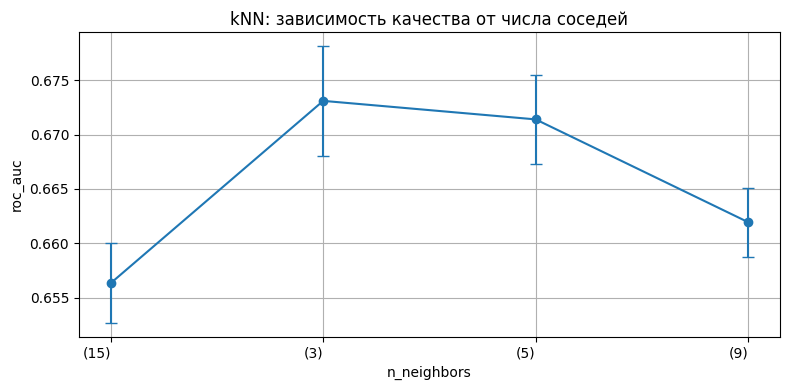

Best parameters: {'n_neighbors': 3}
Best CV mean roc_auc: 0.673110675224117


In [418]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier()
param_grid_knn = {
    "n_neighbors": [3, 5, 9, 15]
}

gs_knn = grid_search_with_plot(
    model=knn,
    param_grid=param_grid_knn,
    
    X=X_num_np,
    y=y_np,
    params_name="n_neighbors",
    title="kNN: зависимость качества от числа соседей"
)

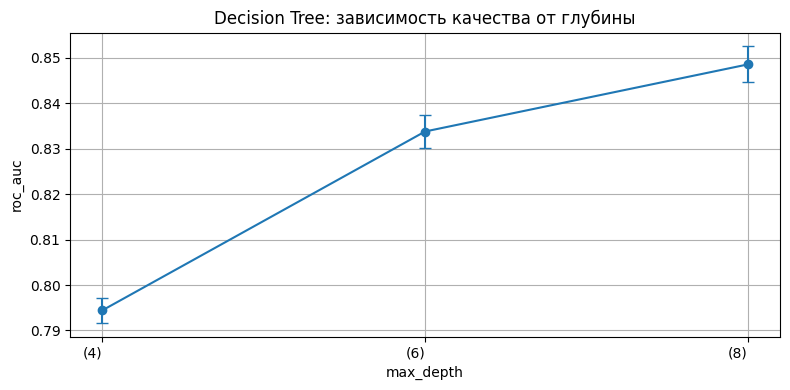

Best parameters: {'max_depth': 8}
Best CV mean roc_auc: 0.8485812599024687


In [419]:
from sklearn.tree import DecisionTreeClassifier


dt = MyCoolDecisionTreeClassifierOptimized()

param_grid_dt = {
    "max_depth": [4, 6, 8]
}

gs_dt = grid_search_with_plot(
    model=dt,
    param_grid=param_grid_dt,
    X=X_num_np,
    y=y_np,
    params_name="max_depth",
    title="Decision Tree: зависимость качества от глубины"
)

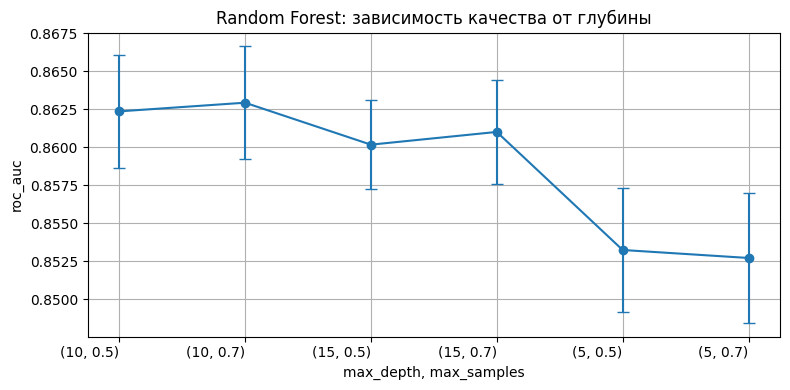

Best parameters: {'max_depth': 10, 'max_samples': 0.7}
Best CV mean roc_auc: 0.8629307511124897


In [420]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

param_grid_rf = {
    "max_depth": [5, 10, 15],
    "max_samples": [0.7, 0.5]
}

gs_rf = grid_search_with_plot(
    model=rf,
    param_grid=param_grid_rf,
    X=X_num_np,
    y=y_np,
    params_name="max_depth, max_samples",
    title="Random Forest: зависимость качества от глубины"
)

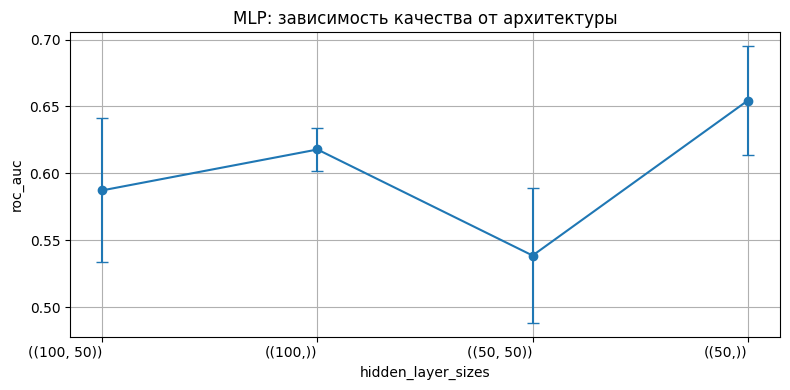

Best parameters: {'hidden_layer_sizes': (50,)}
Best CV mean roc_auc: 0.6544047646721284


In [421]:
from sklearn.neural_network import MLPClassifier


mlp = MLPClassifier(
    max_iter=500,
    random_state=42
)

param_grid_mlp = {
    "hidden_layer_sizes": [
        (50,),
        (100,),
        (50, 50),
        (100, 50)
    ]
}

gs_mlp = grid_search_with_plot(
    model=mlp,
    param_grid=param_grid_mlp,
    X=X_num_np,
    y=y_np,
    params_name="hidden_layer_sizes",
    title="MLP: зависимость качества от архитектуры"
)


Как видно из графиков выше наибольшее среднее качество у RandomForest.  
Самый большой разброс у MLP, так как он очень чувствителен к масштабу гиперпараметров.  
Самые узкие дверительные интервалы у kNN(происходит усредение по сосдеям -> уменьшение дисперсии) и RandomForest (дисперсия уменьшается путём усреднения).

**Задание 3 (1 балл).** Теперь подберём число деревьев (*n_estimators*) в алгоритме RandomForest. Как известно, в общем случае Random Forest не переобучается с увеличением количества деревьев. Подберите количество деревьев, начиная с которого качество на кросс-валидации стабилизируется. Обратите внимание, что для проведения этого эксперимента не нужно с нуля обучать много случайных лесов с разным количеством деревьев: обучите один случайный лес с максимальным интересным количеством деревьев, а затем рассмотрите подмножества деревьев разных размеров, состоящие из деревьев построенного леса (поле [*estimators_*](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)). В дальнейших экспериментах используйте найденное количество деревьев.

Применить класс *GridSearchCV* в данном задании затруднительно, поэтому предлагается самостоятельно написать цикл по числу деревьев.

In [422]:
from sklearn.metrics import roc_auc_score


def rf_n_estimators_cv(
    X,
    y,
    max_estimators=200,
    step=5,
    random_state=42):
   
    cv = KFold(
        n_splits=5, 
        shuffle=True, 
        random_state=random_state)

    mean_scores = []
    std_scores = []
    n_estimators_list = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        rf = RandomForestClassifier(
            n_estimators=max_estimators,
            random_state=random_state,
            n_jobs=-1
        )
        
        rf.fit(X_train, y_train)

        all_probas = np.array([
            tree.predict_proba(X_val)
            for tree in rf.estimators_
        ])

        fold_scores = []
        for k in range(step, max_estimators + 1, step):
            mean_proba = all_probas[:k].mean(axis=0)
            y_pred = mean_proba.argmax(axis=1)
            fold_scores.append(roc_auc_score(y_val, y_pred))

        if not len(mean_scores):
            mean_scores = np.array(fold_scores)
            std_scores = np.zeros_like(mean_scores)
        else:
            mean_scores += np.array(fold_scores)
            std_scores += np.array(fold_scores) ** 2

    n_folds = cv.get_n_splits()
    mean_scores /= n_folds
    std_scores = np.sqrt(std_scores / n_folds - mean_scores ** 2)
    n_estimators_list = list(range(step, max_estimators + 1, step))

    return n_estimators_list, mean_scores, std_scores

C:\Users\Maksim Tseshnaty\AppData\Local\Temp\ipykernel_9408\3073436197.py:52: RuntimeWarning: invalid value encountered in sqrt
  std_scores = np.sqrt(std_scores / n_folds - mean_scores ** 2)


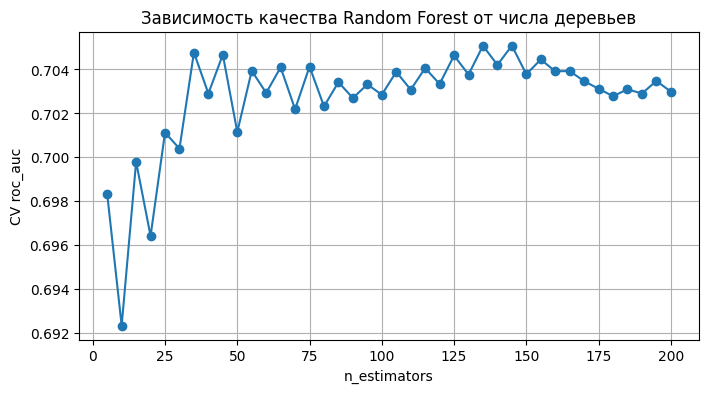

Best n_estimators by mean scores: 145


In [423]:
n_estimators, mean_scores, std_scores = rf_n_estimators_cv(
    X_num_np,
    y_np,
    max_estimators=200,
    step=5
)

plt.figure(figsize=(8, 4))
plt.plot(n_estimators, mean_scores, marker="o")
plt.fill_between(
    n_estimators,
    mean_scores - std_scores,
    mean_scores + std_scores,
    alpha=0.25
)

plt.xlabel("n_estimators")
plt.ylabel("CV roc_auc")
plt.title("Зависимость качества Random Forest от числа деревьев")
plt.grid(True)
plt.show()

print(f"Best n_estimators by mean scores: {n_estimators[np.argmax(mean_scores)]}")

По графику выше видно, что лучшее количество деревьев примерно равно 100-150 для стабилизации скора предсказания.

При обучении алгоритмов стоит обращать внимание не только на их качество, но и каким образом они работают с данными. В этой задаче получилось так, что некоторые из используемых алгоритмов чувствительны к масштабу признаков. Чтобы убедиться, что это могло повлиять на качество, давайте посмотрим на значения самих признаков.

**Задание 4 (0.5 балла).** Посмотрите на значения признаков *age*, *fnlwgt*, *capital-gain*. В чем заключается особенность данных? На какие из рассматриваемых алгоритмов это может повлиять? Может ли масштабирование повлиять на работу этих алгоритмов?

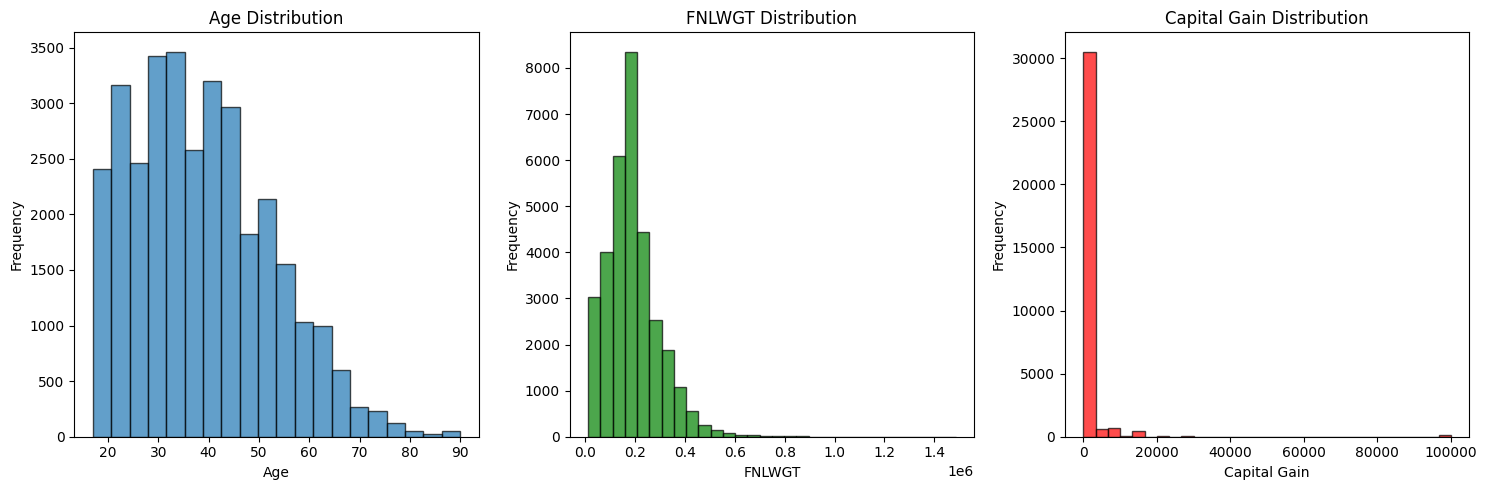

In [424]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))


axes[0].hist(X_num['age'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

axes[1].hist(X_num['fnlwgt'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title("FNLWGT Distribution")
axes[1].set_xlabel("FNLWGT")
axes[1].set_ylabel("Frequency")

axes[2].hist(X_num['capital-gain'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[2].set_title("Capital Gain Distribution")
axes[2].set_xlabel("Capital Gain")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Как видно из гистрам выше, у всех числовых фич разный разброс в значениях, у кого то этот разброз измерятся в десятках тысяч, а у кого в миллионах.  
Из за такого разброса масштаба, алгоритмы, kNN и MLP могут работать не точно (kNN - расстояния между объектами будут неправильно учитываться. MLP - из за больших значений фич, будет взрываться градиент при SGD).

Масштабирование признаков можно выполнить, например, одним из следующих способов:
 - $x_{new} = \dfrac{x - \mu}{\sigma}$, где $\mu, \sigma$ — среднее и стандартное отклонение значения признака по всей выборке (см. функцию [scale](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html))
 - $x_{new} = \dfrac{x - x_{min}}{x_{max} - x_{min}}$, где $[x_{min}, x_{max}]$ — минимальный интервал значений признака

Похожие схемы масштабирования приведены в классах [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) и [MinMaxScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler), причем **строго рекомендуется** использовать именно их, так как во избежание переобучения коэффициенты сдвига и масштаба необходимо считать не по всей выборке, а только по обучающей выборке, то есть применить метод *fit_transform* для обучающей выборки и метод *transform* для тестовой.
 
**Задание 5 (1 балл).** Подберите по кросс-валидации тот вариант масштабирования, который даёт лучшее качество - для каждого типа модели это может быть свой вариант масштабирования, в том числе отсуствие масштабирования тоже считается вариантом). Отмасштабируйте вещественные признаки и подберите оптимальные значения гиперпараметров аналогично пункту выше.

Изменилось ли качество некоторых алгоритмов и почему?

In [425]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


def run_model_with_scalers(
    model,
    param_grid_model: dict,
    X,
    y,
    scoring: str = "roc_auc",
    cv_splits: int = 5,
    random_state: int = 42,
    n_jobs: int = -1,
):

    pipe = Pipeline([
        ("scaler", "passthrough"),
        ("model", model),
    ])

    param_grid = {
        "scaler": [
            "passthrough",
            StandardScaler(),
            MinMaxScaler(),
        ],
    }


    for k, v in param_grid_model.items():
        param_grid[f"model__{k}"] = v
    cv = KFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=random_state
    )

    gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        return_train_score=True,
    )

    gs.fit(X, y)
    return gs


In [426]:
models = {
    "kNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 7, 11],
            "metric": ["euclidean", "minkowski"]
        },
    ),

    "MLP": (
        MLPClassifier(max_iter=500, random_state=42),
        {
            "hidden_layer_sizes": [(100,), (50, 50)],
            "learning_rate": ["constant", "adaptive"],
            "learning_rate_init": [0.001, 0.005]
        }
    ),

    "DecisionTree": (
        MyCoolDecisionTreeClassifierOptimized(),
        {
            "max_depth": [5, 7, 9],
            "min_samples_leaf": [1, 3, 5]
        },
    ),

    "RandomForest": (
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        {
            "min_samples_leaf": [1, 3, 5],
            "max_features": ["sqrt", "log2"]
        },
    ),
}

In [427]:
results = {}

for name, (model, param_grid) in models.items():
    print(f"Running {name}...")

    gs = run_model_with_scalers(
        model=model,
        param_grid_model=param_grid,
        X=X_num_np,
        y=y_np
    )

    results[name] = gs

    print("Best score:", gs.best_score_)
    print("Best params:")
    for k, v in gs.best_params_.items():
        print(f"  {k}: {v}")
    print("-" * 40)


Running kNN...
Best score: 0.8186277126403135
Best params:
  model__metric: euclidean
  model__n_neighbors: 11
  scaler: StandardScaler()
----------------------------------------
Running MLP...
Best score: 0.855339225225892
Best params:
  model__hidden_layer_sizes: (50, 50)
  model__learning_rate: constant
  model__learning_rate_init: 0.005
  scaler: MinMaxScaler()
----------------------------------------
Running DecisionTree...
Best score: 0.8516641417438084
Best params:
  model__max_depth: 9
  model__min_samples_leaf: 5
  scaler: passthrough
----------------------------------------
Running RandomForest...
Best score: 0.859046065550676
Best params:
  model__max_features: sqrt
  model__min_samples_leaf: 5
  scaler: StandardScaler()
----------------------------------------


In [428]:
summary = []

for name, gs in results.items():
    best = gs.best_params_
    summary.append({
        "model": name,
        "best_score": gs.best_score_,
        "scaler": type(best["scaler"]).__name__ if best["scaler"] != "passthrough" else "none",
    })

df_summary = pd.DataFrame(summary).sort_values("best_score", ascending=False)
df_summary


,model,best_score,scaler
3,RandomForest,0.859046,StandardScaler
1,MLP,0.855339,MinMaxScaler
2,DecisionTree,0.851664,none
0,kNN,0.818628,StandardScaler


Как можно выидеть по таблице выше, нормировка числовых фич помогла только MLP и kNN моделям. (И почему то ещё RandomForest...)

Что хорошего для kNN:  
    kNN сравнивает именно расстояния между объектами, поэтому ему важно, чтобы все объекты были отцентрированы, что и делает StandardScaler.  

Что хорошего для MLP:  
    У MLP была проблема именно с взрывом градиента, то есть, само распределение выборки не играло большой роли в качественном обучении, достаточно было просто отнормировать все фичи в каокой то небольшой отрезок, что собственно и делает MinMaxScaler

Пока что лучшая модель, без добавлениия категориальных фич, это RandomForest

**Задание 6 (2 балла).** Теперь сделайте перебор нескольких гиперпараметров по сетке или с помощью оптуны и найдите оптимальные комбинации (лучшее среднее значение качества) для каждого алгоритма в данном случае: 
 - KNN — число соседей (*n_neighbors*) и метрика (*metric*);
 - DecisonTree — глубина дерева (*max_depth*) и минимальное число объектов в листе (*min_samples_leaf*);
 - RandomForest — минимальное число объектов в листе (*min_samples_leaf*) и максимальное число рассматриваемых признаков (*max_features*),  используйте найденное ранее количество деревьев.
 - MLP - структура классификатора (*hidden_layer_sizes*) и скорость обучения (*learning_rate* и *learning_rate_init*)
 
Обратите внимание, что эта операция может быть ресурсоемкой.

Какой из алгоритмов имеет наилучшее качество? 

In [429]:
# Уже сделано выше вместе с перебором scaler

**Задание 7 (1 балл).** Постройте для разных алгоритмов графики [кривых обучения](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html), изображающие зависимость качества на тестовой и обучающей выборках от количества объектов, на которых обучаются модели. Посмотрите на поведение кривых и ответьте на вопросы:
* Может ли с ростом числа объектов убывать качество на тестовой выборке? А на обучающей? Почему?
* Для каких целей можно использовать знание качества на обучающей части выборки?
* Какой из алгоритмов лучше обучается на меньшем числе объектов?
* Может ли добавление новых объектов значительно повысить качество какого-то из алгоритмов или при существующем наборе данных для всех алгоритмов произошло насыщение?

In [430]:
from sklearn.model_selection import learning_curve


def plot_learning_curve(
    estimator,
    X,
    y,
    title: str,
    cv: int = 5,
    scoring: str = "roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs: int = -1,
):

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=42,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(7, 4))

    plt.plot(train_sizes, train_mean, marker="o", label="Train")
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
    )

    plt.plot(train_sizes, val_mean, marker="o", label="Validation")
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2,
    )

    plt.title(title)
    plt.xlabel("Число обучающих объектов")
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [437]:
models = {
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=11,
            metric="euclidean"
        )),
    ]),

    "Decision Tree": Pipeline([
        ("scaler", "passthrough"),
        ("model", MyCoolDecisionTreeClassifierOptimized(
            max_depth=9,
            min_samples_leaf=5
        )),
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            max_samples=0.7,
            random_state=42,
            n_jobs=-1,

            max_features="sqrt",
            min_samples_leaf=5
        )),
    ]),

    "MLP": Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(50, 50),
            max_iter=500,
            random_state=42,
            learning_rate="constant",
            learning_rate_init=0.005
        )),
    ]),
}


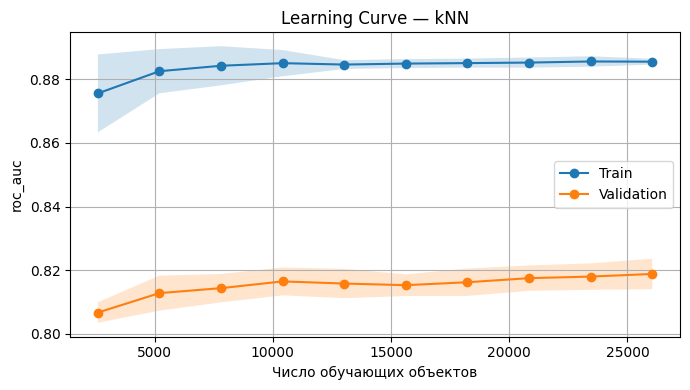

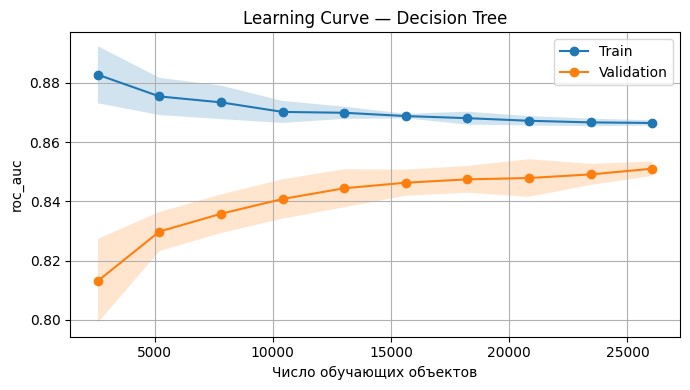

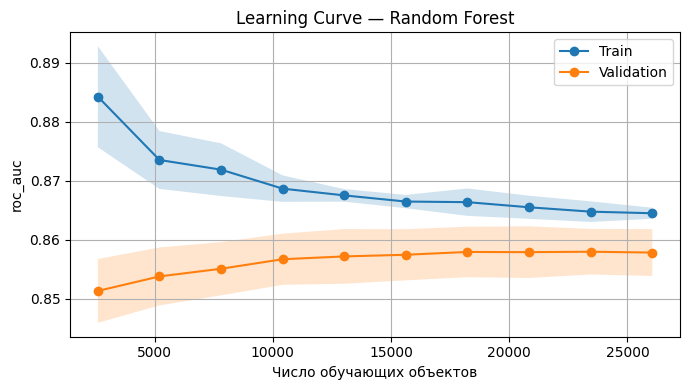

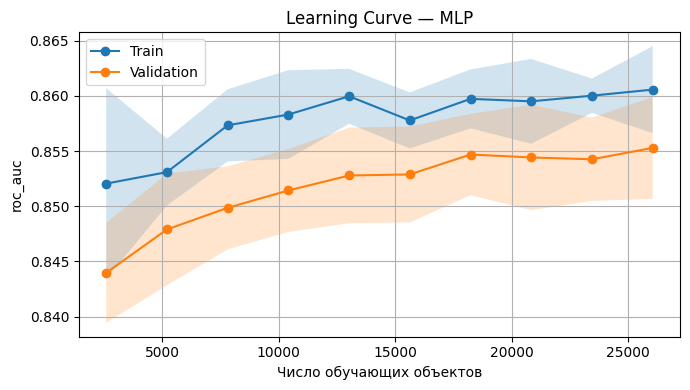

In [438]:
for name, model in models.items():
    plot_learning_curve(
        estimator=model,
        X=X_num_np,
        y=y_np,
        title=f"Learning Curve — {name}",
        cv=5,
        scoring="roc_auc",
    )


Ответы на вопросы:  
1. Как мы видим из графиков выше, на тестовой выборке при увеличении количества обучающих объектов скор только растёт вверх. Но вот на обучающей выборке скор может меняться, притом в худшую сторону - это заметно у RandomForest - происходит это скоре всего из за того, что внутри него происходит bootstrap выборка новых объектов.
2. Изучая скор на train и test можно выявить моменты недообучения модели(низкие скоры на train и test) или наоброт переобучение модели (высокий скор на train, но низкий на test)
3. Лучше всего на маленькой обучающей выборке, судя по графикам выше, обучается DecisionTree и kNN, это видно по неизменному cкору на обчучающей выборке у обоих моделей. Хуже всего обучается MLP, посколько она в разы больше параметров, чем предыдущие алгоритмы, которые надо обучить.
4. Добавлением новых объектов можно повысить качество моделей, но не всех. Так например добавление новых объектов почти не влияет на kNN и DecisionTree, они быстро насыщаются даже маленькой выборкой. С MLP и RandomForest противоположная ситуация.

### 2 Добавление категориальных признаков в модели (2 балла)

Пока мы не использовали нечисловые признаки, которые есть в датасете. Давайте посмотрим, правильно ли мы сделали, и увеличится ли качество моделей после добавлениях этих признаков. 

**Задание 8 (0.5 балла).** Преобразуйте все категориальные признаки с помощью метода one-hot-encoding [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) или используйте встроенные возможности алгоритмов для работы с категориальными фичами.

In [461]:
# Сделано ниже в pipeline)

Так как после кодирования признаков получилось достаточно много, в этой работе мы не будем подбирать заново оптимальные гиперпараметры для моделей с учетом новых признаков (хотя правильнее было бы это сделать). 

**Задание 9 (1.5 балла).** Добавьте к масштабированным вещественным признакам закодированные категориальные и обучите алгоритмы с наилучшими гиперпараметрами, найденными ранее. Дало ли добавление новых признаков прирост качества? Измеряйте качество, как и раньше, используя 5-Fold CV. Для этого удобно воспользоваться функцией [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

Отличается ли теперь наилучший классификатор от наилучшего в предыдущем пункте?

In [454]:
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.model_selection import cross_val_score

def test_model_with_cat_features(
    model_pipeline,
    num_scaler,
    X_num: pd.DataFrame,
    X_cat: pd.DataFrame,
    y,
    cv=5,
    scoring="roc_auc"
):
    X_num = X_num.reset_index(drop=True)
    X_cat = X_cat.reset_index(drop=True)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_scaler, list(X_num.columns)),
            ("cat", categorical_transformer, list(X_cat.columns))
        ],
        remainder="drop" 
    )

    
    full_df = pd.concat([X_num, X_cat], axis=1)

    full_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("to_array", FunctionTransformer(lambda x: np.array(x))),
        ("model", model_pipeline.named_steps["model"]),
    ])

    scores = cross_val_score(
        full_pipeline,
        X=full_df,
        y=y.to_numpy(),
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    return scores.mean(), scores.std(), full_df


In [452]:
X_cat = data[cat_features].apply(lambda col: col.astype(str).mask(col.isna()))
X_cat.isna().any()

workclass          True
education         False
marital-status    False
occupation         True
relationship      False
race              False
sex               False
native-country     True
dtype: bool

In [455]:
results_with_cat = {}

for name, pipe in models.items():
    scaler = pipe.named_steps["scaler"]

    mean_score, std_score, X_pd = test_model_with_cat_features(
        model_pipeline=pipe,
        num_scaler=scaler,
        X_num=X_num,
        X_cat=X_cat,
        y=y,
    )

    results_with_cat[name] = (mean_score, std_score)

    print(
        f"{name:15s}: "
        f"{mean_score:.4f} ± {std_score:.4f}"
    )


kNN            : 0.8827 ± 0.0046
Decision Tree  : 0.9014 ± 0.0035
Random Forest  : 0.9047 ± 0.0032
MLP            : 0.8654 ± 0.0059


После добавление категориальных фич, лучше всего себя показали Decision Tree и Random Forest (Возможно это из за того, чтобы OHE помогает им перебрать больше вариантов удачных разделений в узле).

### 3 Смешивание моделей - blending (3 балла)

Во всех предыдущих пунктах мы получили много моделей, которые могут быть достаточно разными по своей природе. Часто на практике оказывается возможным увеличить качество предсказания путем смешивания разных моделей. Давайте посмотрим, действительно ли такой подход дает прирост в качестве.

Выберите из построенных моделей двух предыдущих пунктов две, которые дали наибольшее начество на кросс-валидации (обозначим их $clf_1$ и $clf_2$). Далее постройте новый классификатор, ответ которого на некотором объекте $x$ будет выглядеть следующим образом:

$$result(x) = clf_1(x) * \alpha + clf_2(x) * (1 - \alpha)$$

где $\alpha$ — гиперпараметр нового классификатора, $0\leqslant\alpha\leqslant1$.

**Задание 10 (1.5 балла).**
При реализации своих моделей хорошей практикой является создание sklearn-совместимых классов. Во-первых, такая реализация будет иметь стандартный интерфейс и позволит другим людям безболезненно обучать реализованные вами модели. Во-вторых, появляется возможность использовать любой функционал пакета sklearn, принимающий на вход модель, например, класс *GridSearchCV*, *learning_curve* и другие.

Создайте классификатор, который инициализируется двумя произвольными классификаторами и параметром $\alpha$. Во время обучения такой классификатор должен обучать обе базовые модели, а на этапе предсказания замешивать предсказания базовых моделей по формуле, указанной выше. 

Для создания пользовательского классификатора необходимо отнаследоваться от базовых классов [BaseEstimator](http://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html), [ClassifierMixin](http://scikit-learn.org/stable/modules/generated/sklearn.base.ClassifierMixin.html) и реализовать методы *\_\_init\_\_, fit, predict и predict_proba*. Пример sklearn-совместимого классификатора с комментариями можно найти [здесь](https://scikit-learn.org/stable/developers/develop.html#api-overview).

Данное задание можно будет зачесть, только если ваш код будет запускаться в следующем задании.

In [456]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone


class MyCoolBlendingClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, clf_1, clf_2, alpha=0.5):
        self.clf_1 = clf_1
        self.clf_2 = clf_2
        self.alpha = alpha

    def fit(self, X, y):
        self.clf_1_ = clone(self.clf_1)
        self.clf_2_ = clone(self.clf_2)

        self.clf_1_.fit(X, y)
        self.clf_2_.fit(X, y)

        self.classes_ = self.clf_1_.classes_

        return self

    def predict_proba(self, X):
        proba_1 = self.clf_1_.predict_proba(X)
        proba_2 = self.clf_2_.predict_proba(X)

        return self.alpha * proba_1 + (1.0 - self.alpha) * proba_2

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


**Задание 11 (1.5 балла).** Теперь выберите два лучших построенных классификатора и обучите стекинг: подберите по сетке от 0 до 1 значение $\alpha$ для этого классификатора. Если класс реализован правильно, то вы cможете использовать *GridSearchCV*, как в случае с обычными классификаторами.
Изобразите на графике среднее качество по фолдам и доверительный интервал в зависимости от $\alpha$.

Дал ли этот подход прирост к качеству по сравнению с моделями, обученными по-отдельности? Поясните, почему даже простой блендинг моделей может влиять на итоговое качество?

Если RandomForest входит в топ-2 ваших алгоритмов, постройте дополнительно стекинг на двух лучших классификаторах без RandomForest, также подберите $\alpha$ и сравните полученный алгоритм с исходными алгоритмами и RandomForest: интересно сравнить два ансамбля.


In [457]:
def test_plot_blending(
        clf_1,
        clf_2,
        X,
        y
):

    blend = MyCoolBlendingClassifier(
        clf_1=clf_1,
        clf_2=clf_2
    )

    param_grid = {
        "alpha": np.linspace(0.0, 1.0, 21)
    }

    gs = GridSearchCV(
        estimator=blend,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    gs.fit(X, y)
    results = gs.cv_results_

    alphas = results["param_alpha"].astype(float)
    mean_scores = results["mean_test_score"]
    std_scores = results["std_test_score"]

    plt.figure(figsize=(8, 4))
    plt.plot(alphas, mean_scores, marker="o")
    plt.fill_between(
        alphas,
        mean_scores - std_scores,
        mean_scores + std_scores,
        alpha=0.2
    )

    plt.xlabel("alpha")
    plt.ylabel("CV score")
    plt.title("Blending: качество в зависимости от alpha")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("Best alpha:", gs.best_params_["alpha"])
    print("Best CV score:", gs.best_score_)

In [458]:
clf_1 = RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            max_samples=0.7,
            random_state=42,
            n_jobs=-1,

            max_features="sqrt",
            min_samples_leaf=5
        )

clf_2 = KNeighborsClassifier(
            n_neighbors=11,
            metric="euclidean"
        )


clf_3 = KNeighborsClassifier(
            n_neighbors=11,
            metric="euclidean"
        )

clf_4 = MLPClassifier(
            hidden_layer_sizes=(50, 50),
            max_iter=500,
            random_state=42,
            learning_rate="constant",
            learning_rate_init=0.005
        )

X_prep_np = preprocessor_all.fit_transform(X_pd)

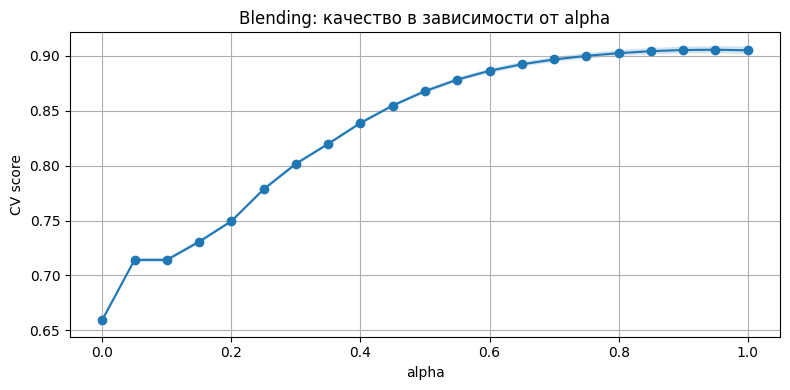

Best alpha: 0.9500000000000001
Best CV score: 0.9053405971226406


In [459]:
test_plot_blending(
    clf_1=clf_1, 
    clf_2=clf_2,
    X=X_prep_np,
    y=y_np
)

Как видим из графика выше, оптималное значение alpha -> 1. То есть RandomForest сам по себе намного лучше, чем его blending с kNN

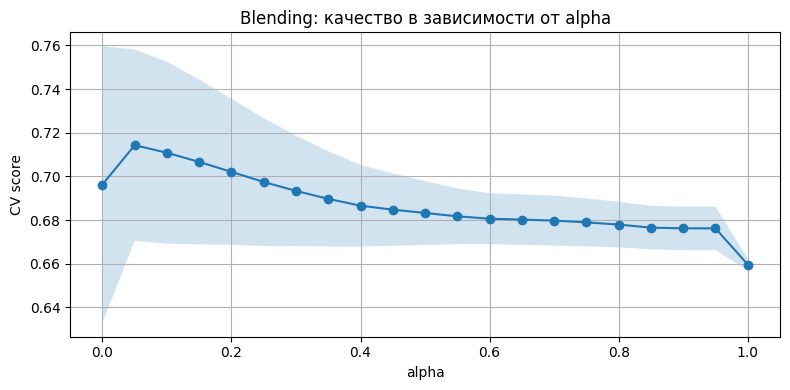

Best alpha: 0.05
Best CV score: 0.7142659863595011


In [462]:
test_plot_blending(
    clf_1=clf_3, 
    clf_2=clf_4,
    X=X_prep_np,
    y=y_np
)

Получилось, что ансамбль из деревьер (лес) всё равно лучше, чем blending из двух разных классификаторов

### 4 Сравнение построенных моделей (1 балл)

![](http://cdn.shopify.com/s/files/1/0870/1066/files/compare_e8b89647-3cb6-4871-a976-2e36e5987773.png?1750043340268621065)

После того, как было построено много моделей, правильным продолжением является сравнение их между собой. Воспользуемся "ящиком с усами" (диаграммой размаха) для сравнения алгоритмов между собой (воспользуйтесь реализацией *box plot* в [seaborn](https://seaborn.pydata.org/generated/seaborn.boxplot.html) или [matplotlib](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.boxplot.html)). 


**Задание 12 (1 балл).** Для каждого типа классификатора (kNN, DecisionTree, Random Forest, MLP), а так же смешанной модели, выберите тот, который давал наилучшее качество на кросс-валидации, и постройте диаграмму размаха. Все классификаторы должны быть изображены на одном графике.
 
Сделайте общие итоговые выводы о классификаторах с точки зрения их работы с признаками и сложности самой модели (какие гиперпараметры есть у модели, сильно ли изменение значения гиперпараметра влияет на качество модели).

In [463]:
# не судьба(